In [10]:
!pip install cartopy
!pip install copernicusmarine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.0/119.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, 

In [1]:
import copernicusmarine

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao"],

    # Slightly shifted north
    minimum_longitude=116.0,
    maximum_longitude=142.3,
    minimum_latitude=26.0,
    maximum_latitude=41.5,

    start_datetime="2026-04-26T00:00:00",
    end_datetime="2026-06-26T00:00:00",

    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,
)

INFO - 2026-07-27T10:17:24Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: sherxonazimov94@gmail.com
Copernicus Marine password: ··········


INFO - 2026-07-27T10:18:09Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-07-27T10:18:09Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-07-27T10:18:09Z - Some of your subset selection [2026-04-26 00:00:00+00:00, 2026-06-26 00:00:00+00:00] for the time dimension exceed the dataset coordinates [1993-01-01 00:00:00+00:00, 2026-06-23 00:00:00+00:00]


  0%|          | [00:00<?]

INFO - 2026-07-27T10:18:21Z - Total size of the download: 6.67 MB.
INFO:copernicusmarine:Total size of the download: 6.67 MB.


ResponseSubset(file_path=PosixPath('cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_116.00E-142.25E_26.00N-41.50N_0.49m_2026-04-26-2026-06-23.nc'), output_directory=PosixPath('.'), filename='cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_116.00E-142.25E_26.00N-41.50N_0.49m_2026-04-26-2026-06-23.nc', file_size=6.666488549618321, data_transfer_size=944.5188396946564, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=116.0, maximum=142.25, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=26.0, maximum=41.5, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2026-04-26T00:00:00+00:00', maximum='2026-06-23T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=0.49402499198913574, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [7]:
import xarray as xr

ds = xr.open_dataset("cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao_116.00E-142.25E_26.00N-41.50N_0.49m_2026-04-26-2026-06-23.nc")

sst = ds['thetao'].squeeze('depth')

In [8]:
vmin = float(sst.min())
vmax = float(sst.max())

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_frame(data, time_value):
    fig = plt.figure(figsize=(12, 8), dpi=200)

    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot SST
    im = ax.pcolormesh(
        ds['longitude'],
        ds['latitude'],
        data,
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax,
        shading='auto',
        transform=ccrs.PlateCarree()
    )

    # Coastlines and features
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # Title
    ax.set_title(f"Sea Surface Temperature\n{str(time_value)[:10]}", fontsize=14)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label("Temperature (°C)")

    return fig

In [10]:
import os

os.makedirs("frames", exist_ok=True)

for i in range(len(sst['time'])):
    data = sst.isel(time=i)
    fig = plot_frame(data, data['time'].values)

    plt.savefig(f"frames/frame_{i:04d}.png", bbox_inches='tight')
    plt.close(fig)

    if i % 1 == 0:
        print(f"Saved frame {i}")

Saved frame 0
Saved frame 1
Saved frame 2
Saved frame 3
Saved frame 4
Saved frame 5
Saved frame 6
Saved frame 7
Saved frame 8
Saved frame 9
Saved frame 10
Saved frame 11
Saved frame 12
Saved frame 13
Saved frame 14
Saved frame 15
Saved frame 16
Saved frame 17
Saved frame 18
Saved frame 19
Saved frame 20
Saved frame 21
Saved frame 22
Saved frame 23
Saved frame 24
Saved frame 25
Saved frame 26
Saved frame 27
Saved frame 28
Saved frame 29
Saved frame 30
Saved frame 31
Saved frame 32
Saved frame 33
Saved frame 34
Saved frame 35
Saved frame 36
Saved frame 37
Saved frame 38
Saved frame 39
Saved frame 40
Saved frame 41
Saved frame 42
Saved frame 43
Saved frame 44
Saved frame 45
Saved frame 46
Saved frame 47
Saved frame 48
Saved frame 49
Saved frame 50
Saved frame 51
Saved frame 52
Saved frame 53
Saved frame 54
Saved frame 55
Saved frame 56
Saved frame 57
Saved frame 58


In [14]:
!ffmpeg -framerate 20 -i frames/frame_%04d.png \
-vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" \
-c:v libx264 -pix_fmt yuv420p -crf 18 -preset slower \
-y sst_highres.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [16]:
from google.colab import files

files.download("sst_highres.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

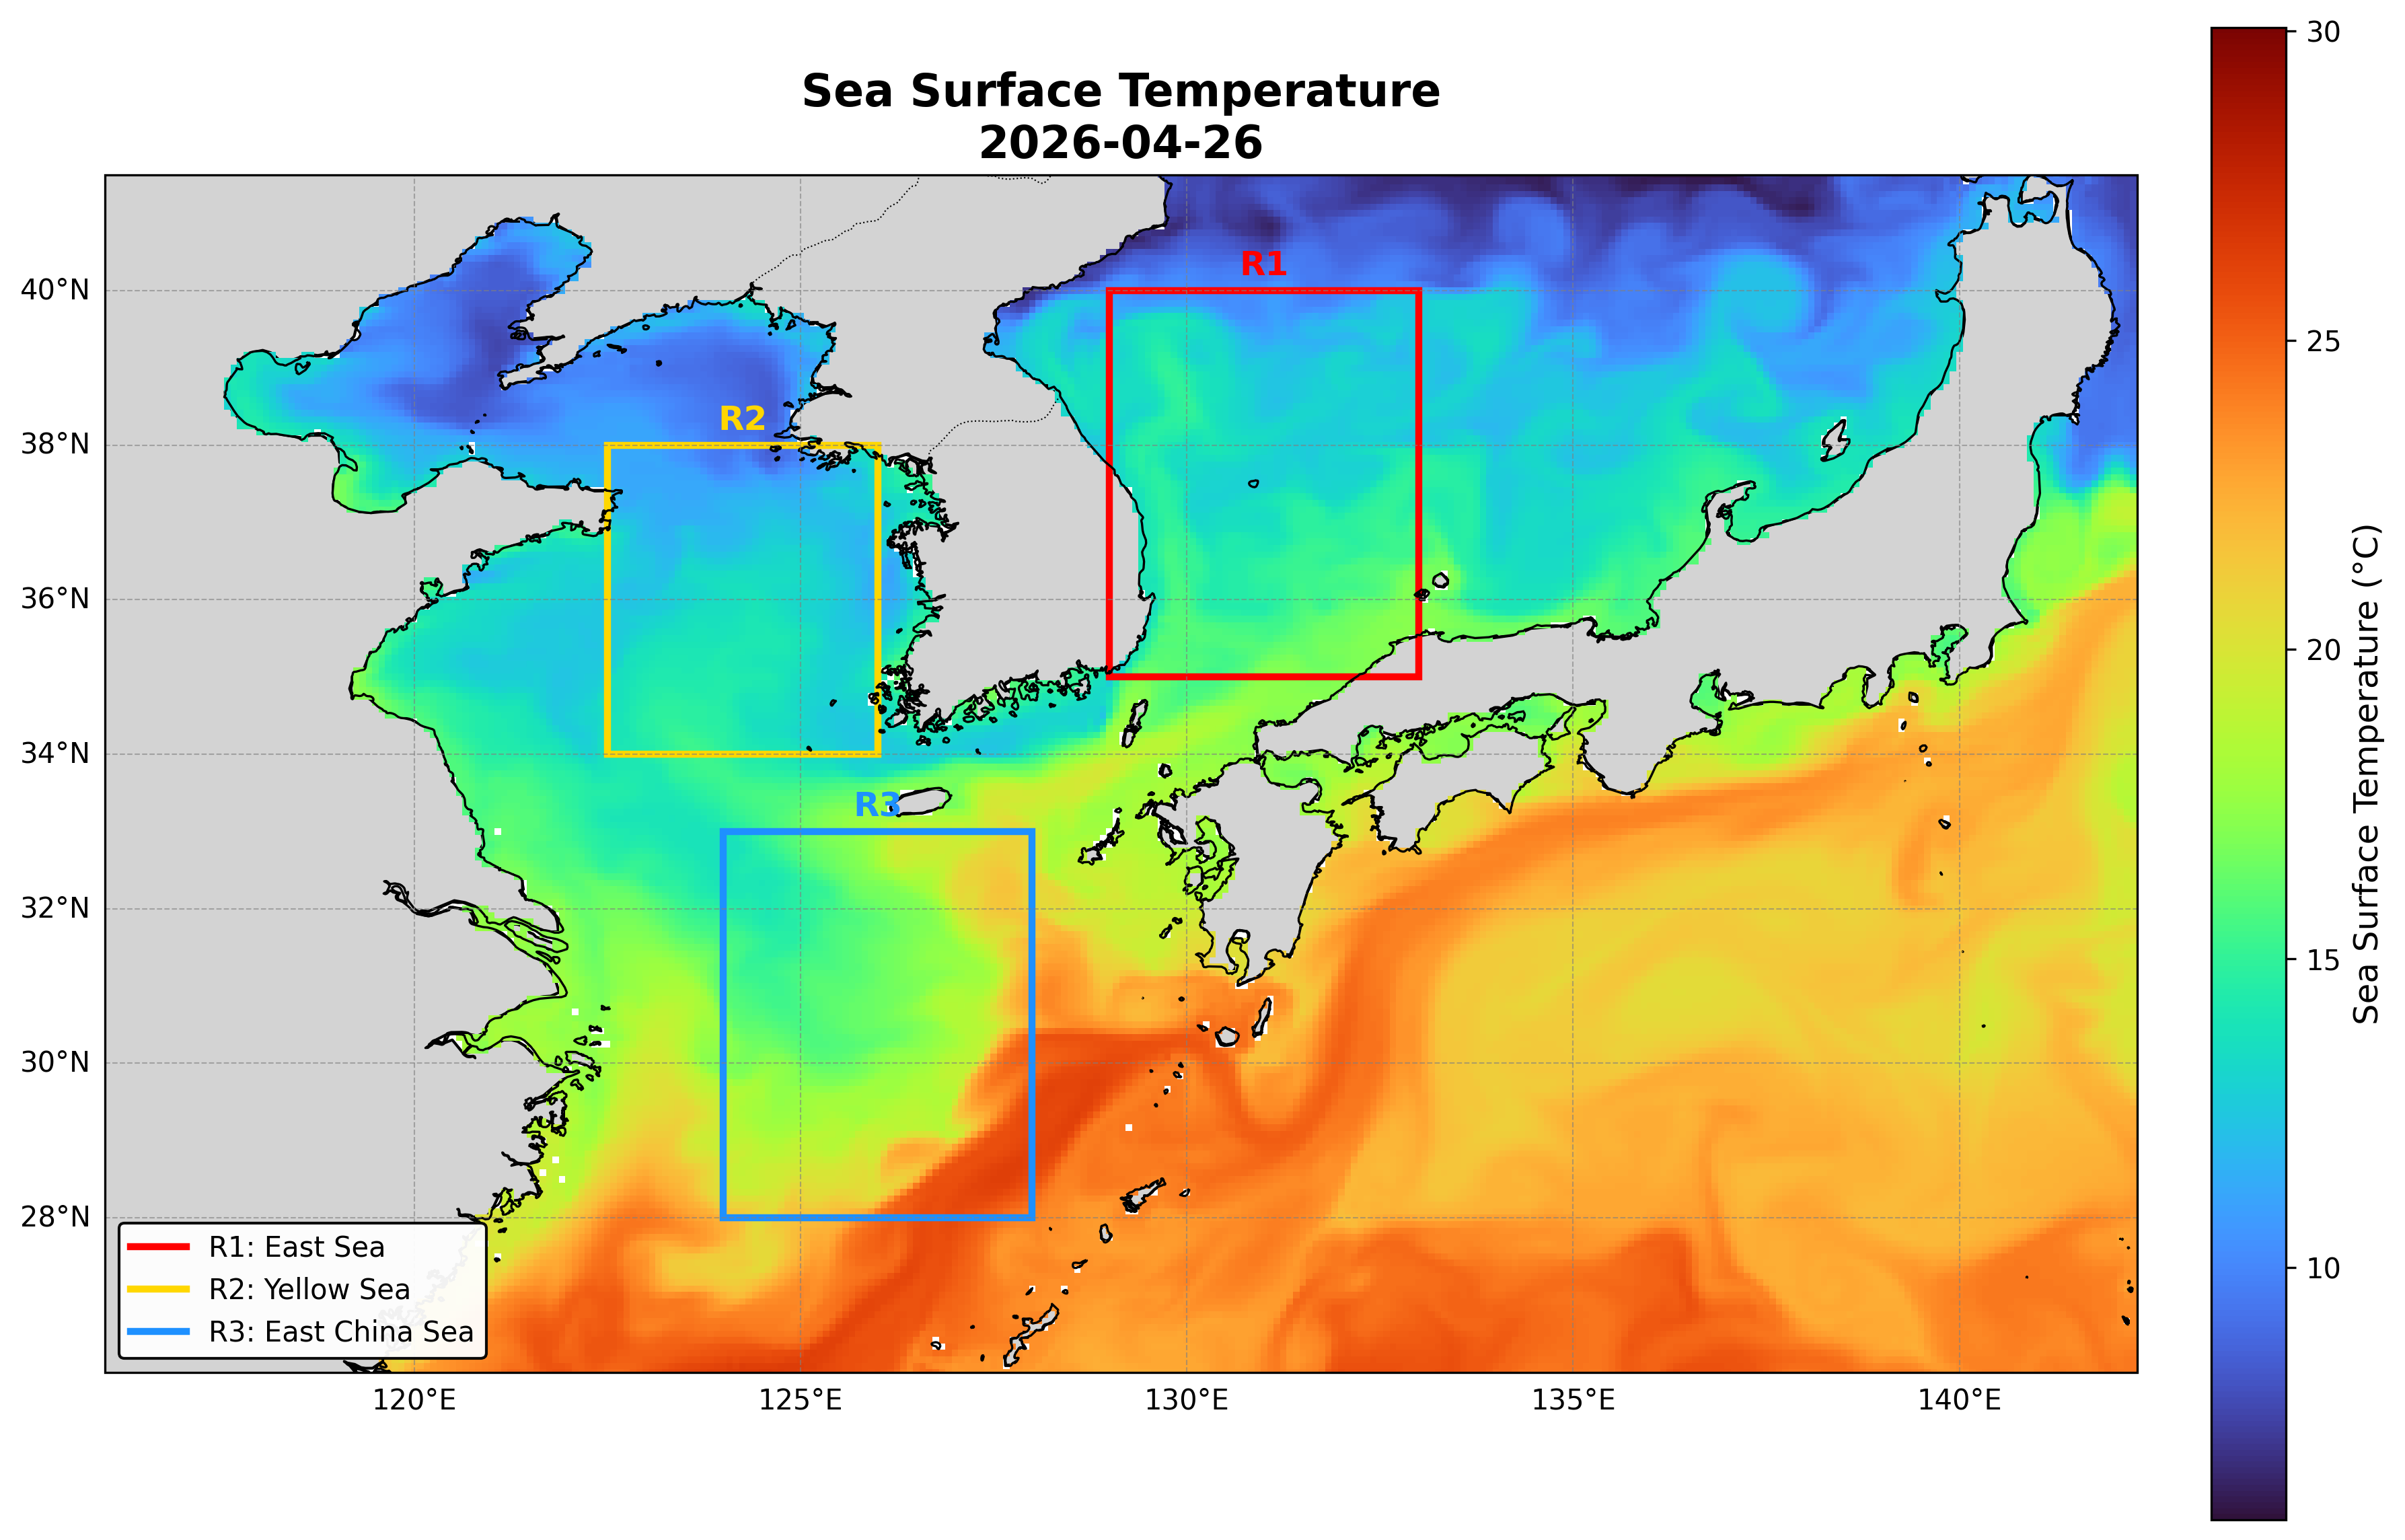

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ==========================================================
# Plot SST with Study Regions
# ==========================================================

def plot_frame(data, time_value):

    # ------------------------------------------------------
    # Figure
    # ------------------------------------------------------
    fig = plt.figure(figsize=(13, 9), dpi=300)

    ax = plt.axes(projection=ccrs.PlateCarree())

    # ------------------------------------------------------
    # Map Extent
    # ------------------------------------------------------
    ax.set_extent([116.0, 142.3, 26.0, 41.5],
                  crs=ccrs.PlateCarree())

    # ------------------------------------------------------
    # SST
    # ------------------------------------------------------
    im = ax.pcolormesh(
        ds.longitude,
        ds.latitude,
        data,
        shading='auto',
        cmap='turbo',          # 'coolwarm' also works
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    # ------------------------------------------------------
    # Coastlines & Land
    # ------------------------------------------------------
    ax.coastlines(resolution='10m', linewidth=0.8)

    ax.add_feature(
        cfeature.LAND,
        facecolor='lightgray',
        edgecolor='black'
    )

    ax.add_feature(
        cfeature.BORDERS,
        linestyle=':',
        linewidth=0.5
    )

    # ------------------------------------------------------
    # Gridlines
    # ------------------------------------------------------
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        linestyle='--',
        color='gray',
        alpha=0.6
    )

    gl.top_labels = False
    gl.right_labels = False

    gl.xlabel_style = {'size':10}
    gl.ylabel_style = {'size':10}

    # ======================================================
    # Study Region R1 : East Sea
    # ======================================================

    ax.add_patch(
        Rectangle(
            (129.0, 35.0),
            4.0,
            5.0,
            fill=False,
            edgecolor='red',
            linewidth=2.5,
            transform=ccrs.PlateCarree()
        )
    )

    ax.text(
        131.0,
        40.2,
        "R1",
        color='red',
        fontsize=12,
        fontweight='bold',
        ha='center',
        transform=ccrs.PlateCarree()
    )

    # ======================================================
    # Study Region R2 : Yellow Sea
    # ======================================================

    ax.add_patch(
        Rectangle(
            (122.5, 34.0),
            3.5,
            4.0,
            fill=False,
            edgecolor='gold',
            linewidth=2.5,
            transform=ccrs.PlateCarree()
        )
    )

    ax.text(
        124.25,
        38.2,
        "R2",
        color='gold',
        fontsize=12,
        fontweight='bold',
        ha='center',
        transform=ccrs.PlateCarree()
    )

    # ======================================================
    # Study Region R3 : East China Sea
    # ======================================================

    ax.add_patch(
        Rectangle(
            (124.0, 28.0),
            4.0,
            5.0,
            fill=False,
            edgecolor='dodgerblue',
            linewidth=2.5,
            transform=ccrs.PlateCarree()
        )
    )

    ax.text(
        126.0,
        33.2,
        "R3",
        color='dodgerblue',
        fontsize=12,
        fontweight='bold',
        ha='center',
        transform=ccrs.PlateCarree()
    )

    # ======================================================
    # Legend
    # ======================================================

    legend_handles = [
        Line2D(
            [0], [0],
            color='red',
            lw=2.5,
            label='R1: East Sea'
        ),
        Line2D(
            [0], [0],
            color='gold',
            lw=2.5,
            label='R2: Yellow Sea'
        ),
        Line2D(
            [0], [0],
            color='dodgerblue',
            lw=2.5,
            label='R3: East China Sea'
        )
    ]

    ax.legend(
        handles=legend_handles,
        loc='lower left',
        fontsize=10,
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        facecolor='white',
        edgecolor='black'
    )

    # ------------------------------------------------------
    # Title
    # ------------------------------------------------------
    ax.set_title(
        f"Sea Surface Temperature\n{str(time_value)[:10]}",
        fontsize=16,
        fontweight='bold'
    )

    # ------------------------------------------------------
    # Colorbar
    # ------------------------------------------------------
    cbar = plt.colorbar(
        im,
        ax=ax,
        shrink=0.85,
        pad=0.03
    )

    cbar.set_label(
        "Sea Surface Temperature (°C)",
        fontsize=12
    )

    # ------------------------------------------------------
    # Layout
    # ------------------------------------------------------
    plt.tight_layout()

    return fig


# ==========================================================
# Example
# ==========================================================

time_index = 0

fig = plot_frame(
    ds.thetao.isel(time=time_index, depth=0).values,
    ds.time.values[time_index]
)

plt.savefig(
    "Representative_Oceanographic_Domains.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()